# This notebook study how conserve the local neighborhoods are across:
1. Normalized count matrix
2. PCA embedding
3. UMAP embedding

### Utilities (define key variables; load packages)

In [35]:
from pathlib import Path
from sklearn.manifold import SpectralEmbedding
from umap.umap_ import nearest_neighbors
from sklearn.utils import check_random_state
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import Colormap
import pandas as pd
import numpy as np

project_workdir = Path("/home/woodydrylab/DiskArray/b05b01002/project_umap_re/")
path_param_sets = project_workdir / "outputs/UMAP/param_table.csv"
path_seed_list = project_workdir / "outputs/UMAP/seeds.txt"

# class holding file paths
class PathFactory:
    def __init__(self, base):
        self._templates = {
            "ica": base / "outputs/InterClusterAngle/{sample}/seed{seed}.csv",
            "cluster": base / "outputs/Seurat/{sample}/clusters.csv",
            "pca": base / "outputs/Seurat/{sample}/pca.csv",
            "umap_embedding": base / "outputs/UMAP/{sample}/seed{seed}/param_set{param_set}.csv",
            "ica_aligned": base / (
                "outputs/InterClusterAngle/{sample}/per_{n}_embeddings/param_set{param_set}_median.csv"
            ),
            "aligned_rmsd": base / (
                "outputs/AlignEmbeddings/procrustes_alignment/{sample}/"
                "per_{n}_embeddings/param_set{param_set}/batch_{batch}/mean_rmsd.csv"
            ),
            "outdir": base / "notebooks/inter-cluster-angle/temp/results_20260123/{sample}"
        }

    @staticmethod
    def path_maker(template, **kwargs):
        template = str(template)
        for k, v in kwargs.items():
            template = template.replace("{"+ k +"}", str(v))
        return Path(template)

    def __getattr__(self, name):
        template = self._templates[name]
        return lambda **kwargs: PathFactory.path_maker(template, **kwargs)

paths = PathFactory(project_workdir)

# hyperparameters
metric = "cosine"
n_neighbors = 100
min_dist = 0.3
n_epochs = 200

# 
seed_min = 62994
seed_max = 72277
seed_random1 = 26483
seed_random2 = 59692
seed_random3 = 74032
seed_random4 = 22363
seeds = [seed_min, seed_max, seed_random1, seed_random2, seed_random3, seed_random4]

Read param table

In [2]:
param_table = pd.read_csv(project_workdir / "outputs/UMAP/param_table.csv", index_col=0)
mask1 = param_table["metric"] == metric
mask2 = param_table["n_neighbors"] == n_neighbors
mask3 = param_table["min_dist"] == min_dist
mask4 = param_table["n_epochs"] == n_epochs
param_table[mask1 & mask2 & mask3 & mask4]

,n_neighbors,min_dist,metric,n_epochs
param_set,,,,
245,100,0.3,cosine,200


Read PCA embeddings

In [25]:
pca_embedding = pd.read_csv(paths.pca(sample="ath"), index_col=0)
pca_embedding.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28,PC_29,PC_30
AAACCCAAGAGCCATG,20.831715,-31.994203,6.104183,-1.960012,-0.095928,-1.637533,0.335895,0.079754,2.557444,-2.684329,...,-0.221850,5.675216,-0.524887,-4.016526,-1.748435,-0.876252,-0.217463,-1.970086,0.864853,0.833307
AAACCCAAGCTGAAGC,6.785328,4.526780,-4.066406,-0.926329,5.874739,0.320644,-1.125884,-1.523293,-7.802383,2.850227,...,-0.508347,-2.428344,0.462367,1.539195,0.655590,-1.434449,2.622180,1.672280,-4.310781,-7.339155
AAACCCAAGGAAGAAC,-17.123725,-2.282723,8.450586,-0.431537,-0.926135,-3.183956,2.394005,2.001158,1.315742,-0.071938,...,-5.002226,1.632814,-6.088313,3.789760,3.921893,-0.965956,3.172862,-5.883861,-2.429831,0.554849
AAACCCAAGGGAGAAT,27.090218,14.249254,15.615403,0.500376,-19.741768,-6.310667,-1.184148,-0.984509,-0.082867,0.975997,...,-3.198190,8.830442,1.099053,-0.475824,-6.758186,-0.588615,-0.221796,-2.050986,2.497152,-1.378548
AAACCCAAGGGTGAGG,-0.207410,-3.394277,-13.927821,0.996488,-2.504883,0.301802,-3.152703,-0.764735,2.873765,6.033640,...,0.063390,3.718860,2.652859,4.124363,5.280334,2.540872,-3.884447,0.538107,0.547711,-2.694082


Read cell clusters

In [28]:
cluster = pd.read_csv(
    paths.cluster(sample="ath"),
    index_col=0,
    dtype=str,
    header=0,
    names=["cluster"]
)
cluster.head()

,cluster
AAACCCAAGAGCCATG,9
AAACCCAAGCTGAAGC,7
AAACCCAAGGAAGAAC,0
AAACCCAAGGGAGAAT,6
AAACCCAAGGGTGAGG,4


Read UMAP embedding

In [14]:
umap_embeddings = {}
for seed in seeds:
    umap_embeddings[seed] = pd.read_csv(
        paths.umap_embedding(sample="ath", seed=seed, param_set=245),
        index_col=0
    )

Find neighbors on PCA embedding

In [5]:
random_state = check_random_state(42)
knn_pca = nearest_neighbors(
    pca_embedding.values,
    n_neighbors=n_neighbors,
    metric=metric,
    metric_kwds=None,
    angular=metric in (
        "cosine",
        "correlation",
        "dice",
        "jaccard",
        "ll_dirichlet",
        "hellinger"
    ),
    random_state=random_state,
    low_memory=True,
    use_pynndescent=True,
    n_jobs=1,
    verbose=True
)

Wed Jan 28 17:44:16 2026 Finding Nearest Neighbors
Wed Jan 28 17:44:16 2026 Building RP forest with 13 trees
Wed Jan 28 17:44:21 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Wed Jan 28 17:44:50 2026 Finished Nearest Neighbor Search


Find neighbors on UMAP embedding

In [15]:
knn_umap = {}
for seed in seeds:
    random_state = check_random_state(42)
    knn_umap[seed] = nearest_neighbors(
        umap_embeddings[seed].values,
        n_neighbors=n_neighbors,
        metric=metric,
        metric_kwds=None,
        angular=metric in (
            "cosine",
            "correlation",
            "dice",
            "jaccard",
            "ll_dirichlet",
            "hellinger"
        ),
        random_state=random_state,
        low_memory=True,
        use_pynndescent=True,
        n_jobs=1,
        verbose=True
    )

Wed Jan 28 17:54:22 2026 Finding Nearest Neighbors
Wed Jan 28 17:54:22 2026 Building RP forest with 13 trees
Wed Jan 28 17:54:22 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Wed Jan 28 17:54:40 2026 Finished Nearest Neighbor Search
Wed Jan 28 17:54:40 2026 Finding Nearest Neighbors
Wed Jan 28 17:54:40 2026 Building RP forest with 13 trees
Wed Jan 28 17:54:40 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Wed Jan 28 17:54:57 2026 Finished Nearest Neighbor Search
Wed Jan 28 17:54:57 2026 Finding Nearest Neighbors
Wed Jan 28 17:54:57 2026 Building RP forest with 13 trees
Wed Jan 28 17:54:57 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Wed Jan 28 17:55:14 2026 Finished Nearest Neighbor Search
Wed Jan 28 17:55:14 2026 Finding Nearest Neighbors
Wed Jan 28 17:55:14 2026 Building RP forest with 13 trees


In [49]:
from matplotlib import colormaps
cmap = colormaps["viridis_r"].resampled(256)

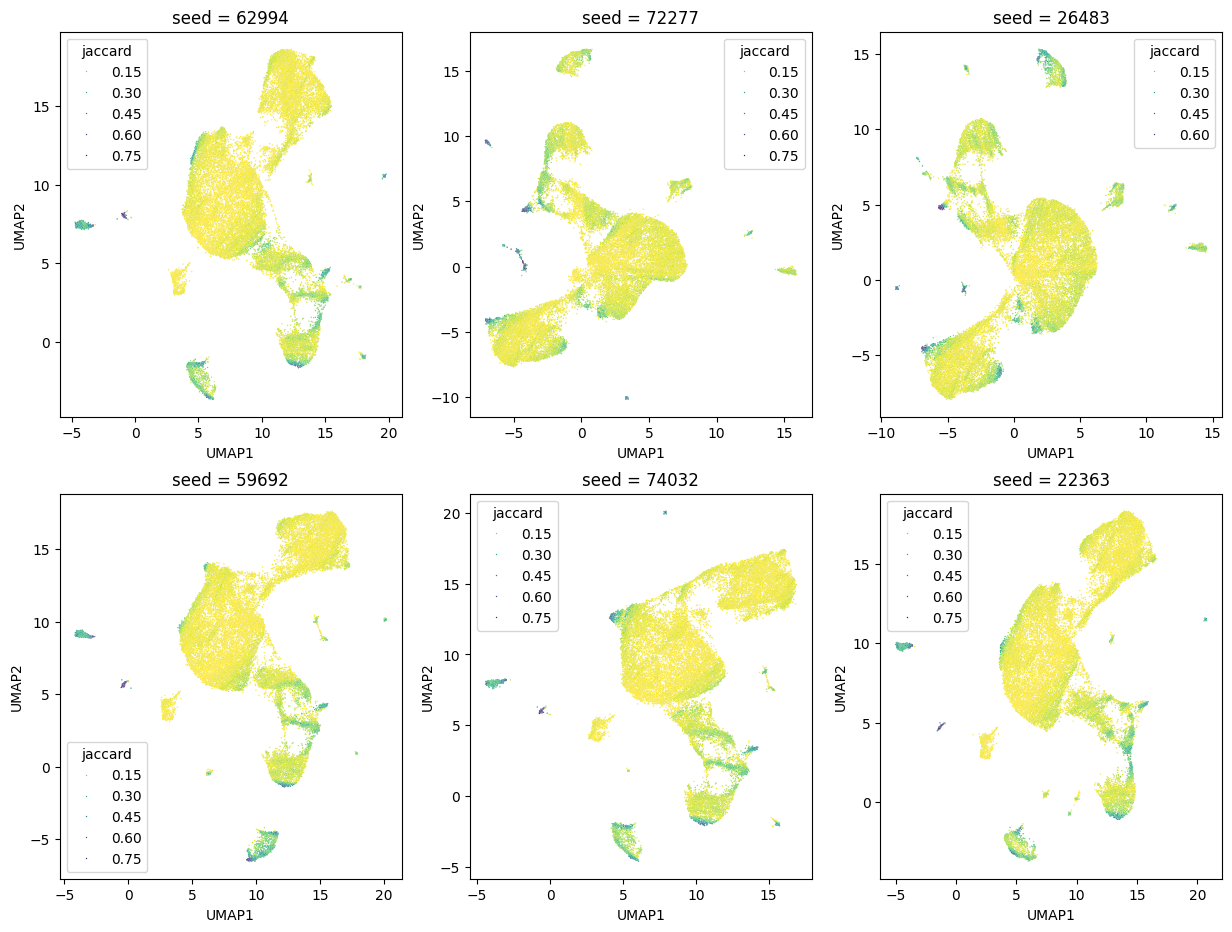

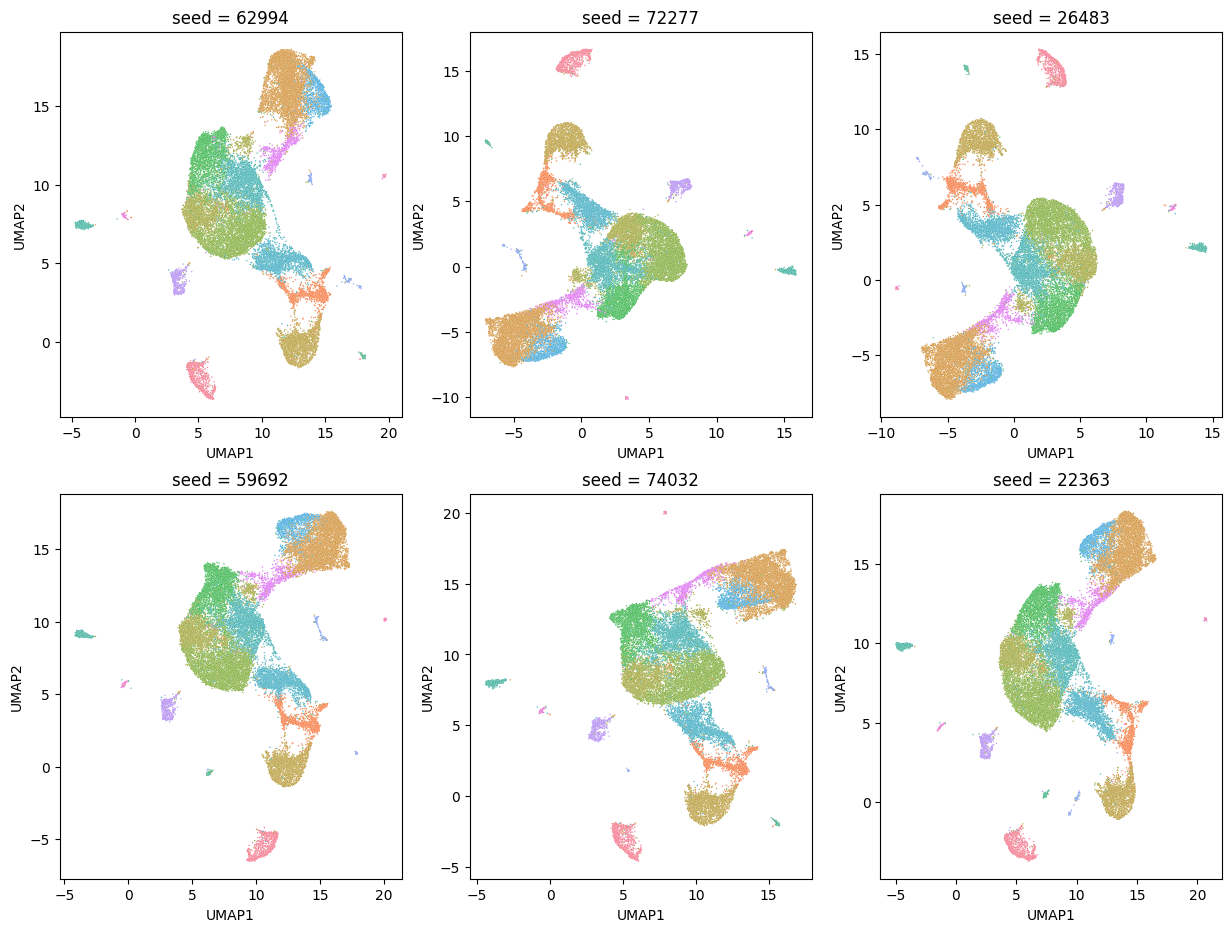

In [53]:
def jaccard(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

jaccard_indices = {}
fig1, axes1 = plt.subplots(len(seeds) // 3, 3, figsize=(15, 11))
fig2, axes2 = plt.subplots(len(seeds) // 3, 3, figsize=(15, 11))

for seed, ax1, ax2 in zip(seeds, axes1.flatten(), axes2.flatten()):
    # calculate jaccard index
    jaccard_indices[seed] = []
    for idx in range(pca_embedding.shape[0]):
        nn_pca = knn_pca[0][idx]
        nn_umap = knn_umap[seed][0][idx]
        jaccard_index = jaccard(set(nn_pca), set(nn_umap))
        jaccard_indices[seed].append(jaccard_index)

    # plot UMAP embedding colored by jaccard index
    data = umap_embeddings[seed].copy()
    data = data.merge(cluster, left_index=True, right_index=True)
    data["cluster"][data["cluster"].astype(int) > 8]
    data["jaccard"] = jaccard_indices[seed]
    sns.scatterplot(
        data,
        x="UMAP1",
        y="UMAP2",
        hue="jaccard",
        palette=cmap,
        ax=ax1,
        s=1
    )
    ax1.set_title(f"seed = {seed}")
    sns.scatterplot(
        data,
        x="UMAP1",
        y="UMAP2",
        hue="cluster",
        ax=ax2,
        s=1,
        legend=False
    )
    ax2.set_title(f"seed = {seed}")